In [2]:
import sys
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from ext.portfolio_math import estimate_expected_returns, estimate_covariance_matrix, mean_variance_cost, enforce_portfolio_constraints
from ext.sgd_optimizer import run_sgd, initialize_weights
from ext.portfolio_backtest import run_portfolio_backtest
from ext.ml_signals import build_ml_signals, build_features, build_target
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import TimeSeriesSplit



In [3]:
# ============================================================
# 1. DONNÉES CAC 40
# ============================================================

tickers = ["TTE.PA", "SAN.PA", "BNP.PA", "AIR.PA", "MC.PA",
           "OR.PA",  "SU.PA",  "DG.PA",  "RI.PA",  "KER.PA"]

raw = yf.download(tickers, start="2020-01-01", end="2026-05-02", auto_adjust=True)
prices = raw["Close"].dropna()
returns = prices.pct_change().dropna()

print(f"Période : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Actifs  : {list(returns.columns)}")
print(f"Jours   : {len(returns)}")

[*********************100%***********************]  10 of 10 completed


Période : 2020-01-03 → 2026-04-30
Actifs  : ['AIR.PA', 'BNP.PA', 'DG.PA', 'KER.PA', 'MC.PA', 'OR.PA', 'RI.PA', 'SAN.PA', 'SU.PA', 'TTE.PA']
Jours   : 1620


In [4]:
# ============================================================
# 2. PARAMÈTRES MARCHÉ
# ============================================================

mu    = estimate_expected_returns(returns)        # rendements moyens journaliers
Sigma = estimate_covariance_matrix(returns)       # matrice de covariance journalière

risk_free_rate_annual = 0.03
risk_free_rate_daily  = risk_free_rate_annual / 252

print(f"Rendement moyen (annualisé) : {mu.mean() * 252:.2%}")
print(f"Taux sans risque journalier : {risk_free_rate_daily:.6f}")

Rendement moyen (annualisé) : 9.25%
Taux sans risque journalier : 0.000119


Poids optimisés :
  TTE.PA   : 0.1000
  SAN.PA   : 0.1000
  BNP.PA   : 0.1000
  AIR.PA   : 0.1000
  MC.PA    : 0.1000
  OR.PA    : 0.1000
  SU.PA    : 0.1000
  DG.PA    : 0.1000
  RI.PA    : 0.1000
  KER.PA   : 0.1000


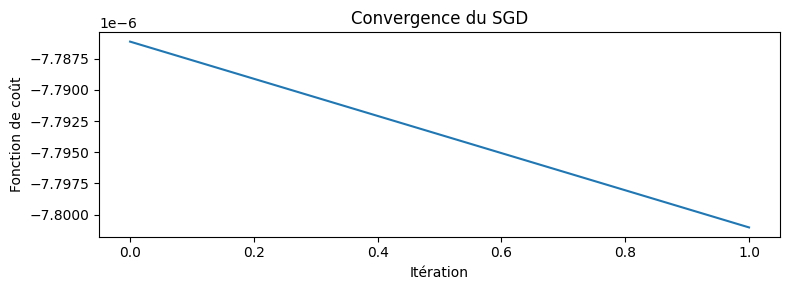

In [5]:
# ============================================================
# 3. OPTIMISATION PAR SGD (mean-variance)
# ============================================================

n_assets = len(tickers)
initial_weights = initialize_weights(n_assets, method="equal")

sgd_results = run_sgd(
    cost_function=mean_variance_cost,
    initial_weights=initial_weights,
    n_iterations=500,
    learning_rate=0.01,
    constraint_function=enforce_portfolio_constraints,
    # kwargs transmis à mean_variance_cost
    expected_returns=mu,
    covariance_matrix=Sigma,
    lambda_risk=2.0,
)

optimized_weights = sgd_results["final_weights"]

print("Poids optimisés :")
for ticker, w in zip(tickers, optimized_weights):
    print(f"  {ticker:8s} : {w:.4f}")

# Convergence
plt.figure(figsize=(8, 3))
plt.plot(sgd_results["cost_history"])
plt.title("Convergence du SGD")
plt.xlabel("Itération")
plt.ylabel("Fonction de coût")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 4. SIGNAUX ML (poids dynamiques)
# ============================================================

ml_results = build_ml_signals(
    price_data=prices,
    returns_data=returns,
    window=20,
    # asset_names est inféré automatiquement depuis prices.columns
)


dynamic_weights = ml_results["weights"]

print(f"Dates disponibles pour le backtest dynamique : {len(dynamic_weights)}")

Dates disponibles pour le backtest dynamique : 1601


In [7]:
# ============================================================
# 5. BACKTEST ET COMPARAISON
# ============================================================

backtest = run_portfolio_backtest(
    returns_matrix=returns,
    optimized_weights=optimized_weights,
    dynamic_weights=dynamic_weights,
    initial_value=1.0,
    risk_free_rate=risk_free_rate_daily,
)

print(backtest["comparison"].to_string())

              cumulative_return  volatility  sharpe_ratio  max_drawdown
equal_weight           0.564634    0.212770      0.293748     -0.391892
optimized              0.564704    0.212769      0.293780     -0.391892
dynamic                4.608264    0.130999      1.908705     -0.082553


In [8]:
# Rendement moyen pour la cible
features     = build_features(prices, returns_data=returns, window=20)
returns_mean = returns.mean(axis=1)
target = build_target(returns_mean, horizon=5, mode="binary")


def walk_forward_predict(features, target, n_splits=50):
    """
    Pour chaque mois :
    - train  : les ~15 premiers jours
    - test   : les ~15 jours suivants
    Le modèle est réentraîné à chaque fenêtre.
    """
    # Aligner features et target
    common   = features.index.intersection(target.index)
    X        = features.loc[common]
    y        = target.loc[common]

    tscv     = TimeSeriesSplit(n_splits=n_splits, test_size=15, gap=0)

    all_signals = pd.Series(0, index=X.index)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr       = y.iloc[train_idx]

        # Normalisation propre à chaque fenêtre
        scaler_wf  = StandardScaler()
        X_tr_sc    = scaler_wf.fit_transform(X_tr)
        X_te_sc    = scaler_wf.transform(X_te)

        # Modèle réentraîné sur cette fenêtre
        model_wf   = LogisticRegression(max_iter=1000)
        model_wf.fit(X_tr_sc, y_tr)

        # Prédiction uniquement sur les 15j de test
        preds = model_wf.predict(X_te_sc)
        all_signals.iloc[test_idx] = preds

        if fold % 10 == 0:
            print(f"Fold {fold:3d} | Train: {X_tr.index[0].date()} → {X_tr.index[-1].date()} "
                  f"| Test: {X_te.index[0].date()} → {X_te.index[-1].date()}")

    return all_signals

# Lancer le walk-forward
signals_wf = walk_forward_predict(features, target, n_splits=50)
print(f"\nDistribution des signaux : {signals_wf.value_counts().to_dict()}")


Fold   0 | Train: 2020-01-30 → 2023-05-23 | Test: 2023-05-24 → 2023-06-13
Fold  10 | Train: 2020-01-30 → 2023-12-19 | Test: 2023-12-20 → 2024-01-12
Fold  20 | Train: 2020-01-30 → 2024-07-24 | Test: 2024-07-25 → 2024-08-14
Fold  30 | Train: 2020-01-30 → 2025-02-24 | Test: 2025-02-25 → 2025-03-17
Fold  40 | Train: 2020-01-30 → 2025-09-25 | Test: 2025-09-26 → 2025-10-16

Distribution des signaux : {0: 1219, 1: 382}


In [9]:
# Convertir les signaux en poids
from ext.ml_signals import signal_to_weights

n_assets       = len(tickers)
dynamic_weights = signal_to_weights(
    signals_wf,
    n_assets=n_assets,
    asset_names=list(returns.columns)
)

# Backtest
backtest = run_portfolio_backtest(
    returns_matrix=returns,
    optimized_weights=optimized_weights,
    dynamic_weights=dynamic_weights,
    initial_value=1.0,
    risk_free_rate=risk_free_rate_daily,
)

print(backtest["comparison"])


              cumulative_return  volatility  sharpe_ratio  max_drawdown
equal_weight           0.564634    0.212770      0.293748     -0.391892
optimized              0.564704    0.212769      0.293780     -0.391892
dynamic                0.620785    0.213382      0.311702     -0.388623


[*********************100%***********************]  1 of 1 completed


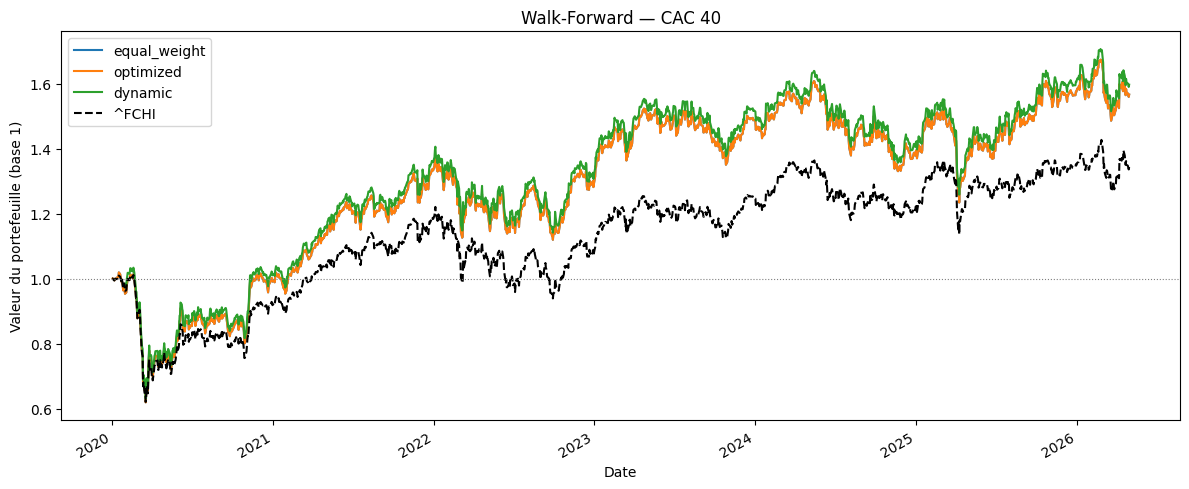

In [10]:
# Visualisation
cac40            = yf.download("^FCHI", start="2020-01-01", end="2026-05-02", auto_adjust=True)["Close"]
cac40_normalized = cac40 / cac40.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))

for name, res in backtest["strategy_results"].items():
    res["portfolio_value"].plot(ax=ax, label=name)

cac40_normalized.plot(ax=ax, label="CAC 40 réel", color="black", linestyle="--", linewidth=1.5)

ax.set_title("Walk-Forward — CAC 40")
ax.set_ylabel("Valeur du portefeuille (base 1)")
ax.axhline(1, color="gray", linestyle=":", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()